# PCA & Dimensionality Reduction

We use Principal Component Analysis (PCA) to reduce our high-dimensional feature space into a smaller set of uncorrelated components.
This helps us:
- **Visualize** participants in 2D/3D
- **Understand** which features drive the most variance
- **Prepare** data for clustering by removing noise and redundancy

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

## 1. Load data

We load the extracted features. Each row is one subject, columns are physiological features + metadata.
We separate the **numeric features** (what PCA will use) from the **metadata** (STAI scores, gender, etc.) which we keep for coloring plots later.

In [31]:
all_features = pd.read_csv("../data/extracted/all_features.csv", index_col=0)
print("Shape:", all_features.shape)

# Separate metadata from numeric features
metadata_cols = ["STAI_T", "STAI_S", "Gender", "Handedness", "WearsGlasses", "CalibrationError", "BloodType"]
feature_cols = [c for c in all_features.select_dtypes(include=np.number).columns if c not in metadata_cols]

print(f"\nNumeric features for PCA: {len(feature_cols)}")
print(f"Metadata columns kept aside: {metadata_cols}")

X = all_features[feature_cols].dropna()
metadata = all_features.loc[X.index, metadata_cols]
print(f"\nSubjects after dropping NaN: {len(X)}")

Shape: (495, 75)

Numeric features for PCA: 68
Metadata columns kept aside: ['STAI_T', 'STAI_S', 'Gender', 'Handedness', 'WearsGlasses', 'CalibrationError', 'BloodType']

Subjects after dropping NaN: 491


## 2. Standardization

PCA is sensitive to the scale of features. A feature measured in BPM (60-80) would dominate one measured in mm (0.01-0.05) simply because of its larger numbers, not because it carries more information.

**StandardScaler** transforms each feature to have mean=0 and std=1, so all features contribute equally to the PCA.

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify: each column should now have mean ~0 and std ~1
print("Mean per feature (should be ~0):", X_scaled.mean(axis=0).round(6)[:5], "...")
print("Std per feature (should be ~1):", X_scaled.std(axis=0).round(6)[:5], "...")

Mean per feature (should be ~0): [ 0. -0. -0. -0. -0.] ...
Std per feature (should be ~1): [1. 1. 1. 1. 1.] ...


## 3. Fit PCA (all components)

We first fit PCA with **all** components to understand the full variance structure.
Each principal component is a linear combination of the original features, ordered by how much variance it explains:
- **PC1** captures the direction of maximum variance
- **PC2** captures the next most variance, orthogonal to PC1
- and so on...

In [33]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

print(f"Total components: {pca_full.n_components_}")
print(f"\nVariance explained by first 5 PCs:")
for i in range(5):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}%")
print(f"  ...")
print(f"  Total (first 5): {sum(pca_full.explained_variance_ratio_[:5])*100:.1f}%")

Total components: 68

Variance explained by first 5 PCs:
  PC1: 14.50%
  PC2: 13.88%
  PC3: 10.22%
  PC4: 8.87%
  PC5: 5.31%
  ...
  Total (first 5): 52.8%


## 4. Scree plot: how many components do we need?

The **scree plot** shows how much variance each component explains.
- The **bar chart** shows individual contribution of each PC
- The **cumulative line** shows the total variance captured as we add more PCs
- The **red dashed line** at 90% is a common threshold: we want enough PCs to explain 90% of the total variance

The "elbow" in the curve tells us where adding more components gives diminishing returns.

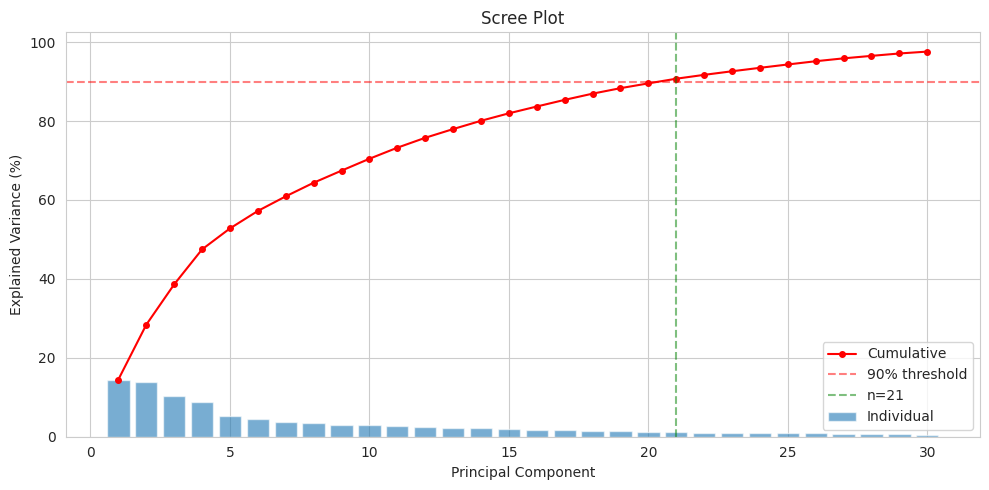


Components needed for 90% variance: 21
Components needed for 95% variance: 26


In [34]:
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_for_90 = int(np.argmax(cumulative >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

n_show = min(30, len(explained))
x = range(1, n_show + 1)

ax.bar(x, explained[:n_show] * 100, alpha=0.6, label="Individual")
ax.plot(x, cumulative[:n_show] * 100, "ro-", markersize=4, label="Cumulative")
ax.axhline(90, color="red", linestyle="--", alpha=0.5, label="90% threshold")
ax.axvline(n_for_90, color="green", linestyle="--", alpha=0.5, label=f"n={n_for_90}")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Scree Plot")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nComponents needed for 90% variance: {n_for_90}")
print(f"Components needed for 95% variance: {int(np.argmax(cumulative >= 0.95) + 1)}")

## 5. PCA with selected number of components

Based on the scree plot, we re-fit PCA keeping only the components needed for 90% variance.
This reduces our feature space from many dimensions to just a few, while retaining most of the information.

In [35]:
pca = PCA(n_components=n_for_90)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions:  {X_pca.shape[1]}")
print(f"Variance retained:   {sum(pca.explained_variance_ratio_)*100:.1f}%")

Original dimensions: 68
Reduced dimensions:  21
Variance retained:   90.7%


## 6. 2D projection: subjects in PC1 vs PC2 space

We project all subjects onto the first two principal components.
- **PC1** (x-axis) is the direction of maximum variance across subjects
- **PC2** (y-axis) is the second most informative direction, orthogonal to PC1

We color subjects by **STAI Trait anxiety** and **STAI State anxiety** to see if anxiety maps onto the physiological feature space.
If anxious and non-anxious subjects separate in this space, it means their physiological profiles are systematically different.

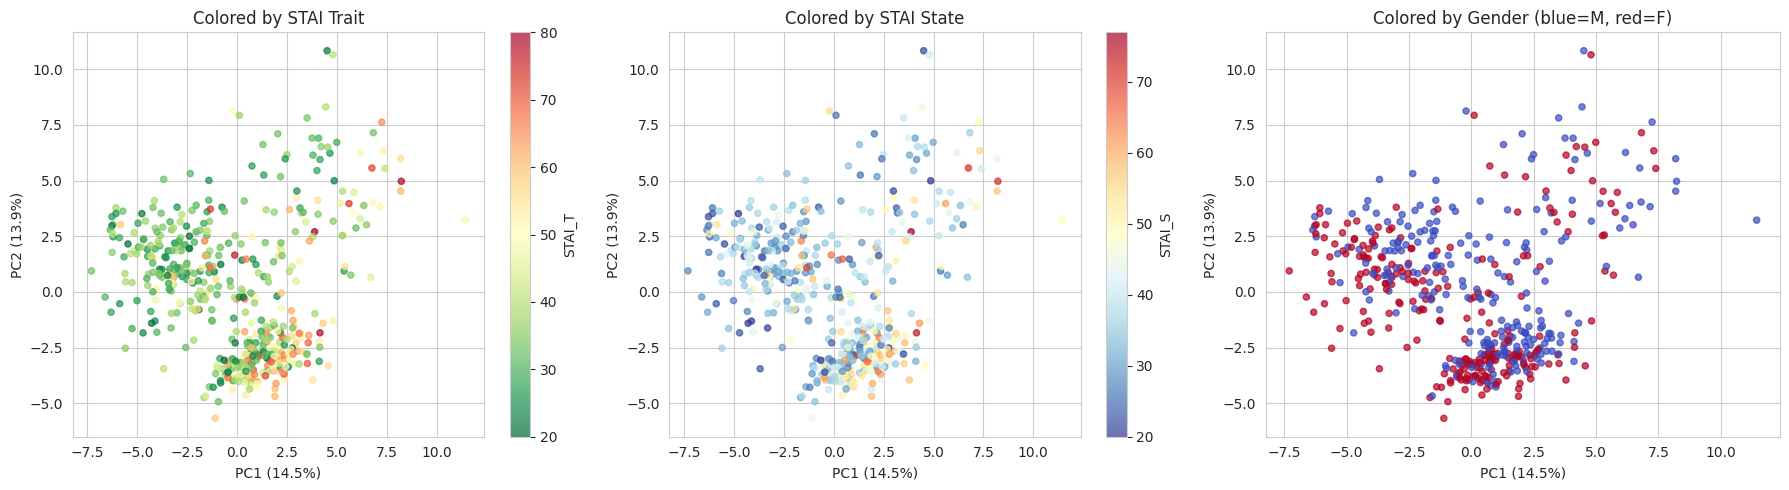

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Color by STAI_T
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=metadata["STAI_T"], cmap="RdYlGn_r", s=20, alpha=0.7)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Colored by STAI Trait")
plt.colorbar(sc0, ax=axes[0], label="STAI_T")

# Color by STAI_S
sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=metadata["STAI_S"], cmap="RdYlBu_r", s=20, alpha=0.7)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Colored by STAI State")
plt.colorbar(sc1, ax=axes[1], label="STAI_S")

# Color by Gender
gender_num = metadata["Gender"].map({"M": 0, "F": 1})
sc2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=gender_num, cmap="coolwarm", s=20, alpha=0.7)
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].set_title("Colored by Gender (blue=M, red=F)")

plt.tight_layout()
plt.show()

## 7. Loadings: what does each PC mean?

The **loadings** tell us the weight (contribution) of each original feature to each principal component.
- A **high positive loading** means that feature pushes a subject to the right (positive direction) on that PC
- A **high negative loading** means the opposite
- A **loading near zero** means the feature is irrelevant for that PC

By looking at the top loadings, we can *interpret* what each PC represents in physiological terms.
For example, if PC1 has high loadings on PupilMean and PulseMean, it represents overall "arousal level".

In [37]:
# Build loadings DataFrame: rows = features, columns = PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print("Loadings shape:", loadings.shape)
loadings.head(10)

Loadings shape: (68, 21)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21
PupilMean,0.230500,0.022793,0.049599,0.266560,-0.012876,0.041601,0.011846,0.019976,-0.061274,-0.025415,...,-0.034730,-0.018133,-0.015386,-0.015002,0.022690,-0.028069,0.004048,0.002733,-0.033067,-0.003450
PupilStd,0.028232,0.248468,0.093528,0.066218,0.016188,-0.165097,0.067980,-0.015903,0.131135,0.008689,...,0.140608,0.028980,0.058956,0.038428,-0.063012,0.158846,-0.162708,0.019986,0.011980,0.055421
PupilIQR,0.005516,0.227650,0.091342,0.085952,0.021779,-0.165850,0.054787,-0.027959,0.157553,0.029766,...,0.132013,0.005434,0.062477,0.063892,-0.076629,0.168323,-0.143915,0.010926,0.023228,0.081488
PulseMean,-0.038874,-0.063655,0.366070,-0.039883,0.003674,0.014074,-0.014184,-0.000670,-0.007953,-0.021915,...,-0.014548,-0.005380,-0.003678,-0.005077,0.021981,-0.007034,0.025645,-0.007977,0.019970,-0.001466
PulseStd,-0.025120,-0.048340,-0.010522,0.042655,-0.103674,-0.045337,-0.357904,-0.231353,0.004485,-0.182953,...,-0.138459,0.104640,-0.032496,0.236548,0.069147,0.020429,-0.137457,-0.012796,-0.042147,0.091905
PulseIQR,-0.009967,-0.029273,-0.033412,0.036534,-0.108141,0.059018,-0.371318,-0.137373,0.012586,-0.170721,...,-0.044720,0.052264,-0.037419,0.242368,-0.021906,0.021021,-0.045667,-0.071262,-0.070274,0.095187
MotionMean,-0.028283,-0.003588,0.004534,-0.045616,-0.025659,0.066598,0.397679,-0.245816,-0.245557,-0.078575,...,-0.135877,-0.042156,0.114510,0.117498,-0.023166,0.000247,0.028179,0.071646,0.045538,-0.035932
MotionStd,-0.032137,-0.009747,-0.003732,-0.044059,-0.029032,0.076370,0.387459,-0.232448,-0.240073,-0.082310,...,-0.114277,-0.017796,0.062321,0.159868,0.012987,0.022364,0.008301,0.065122,0.214491,-0.033180
GazeXSpread,0.072740,0.100353,-0.001083,-0.082917,-0.028248,0.130137,-0.020123,0.063357,-0.005011,-0.015487,...,-0.182368,0.152549,-0.041956,0.165496,-0.010891,0.237303,-0.151409,0.008834,-0.107823,-0.378391
GazeYSpread,0.078344,0.104974,0.012057,-0.106802,0.021446,-0.000276,0.017440,-0.014464,-0.067674,0.015304,...,-0.181909,0.067689,0.031635,0.049693,-0.131905,-0.109892,0.011858,0.110594,-0.250996,0.711048


### 7a. Top loadings for PC1 and PC2

We show the **top 15 features** (by absolute loading) for the first two PCs.
This tells us which physiological features most strongly define each component.

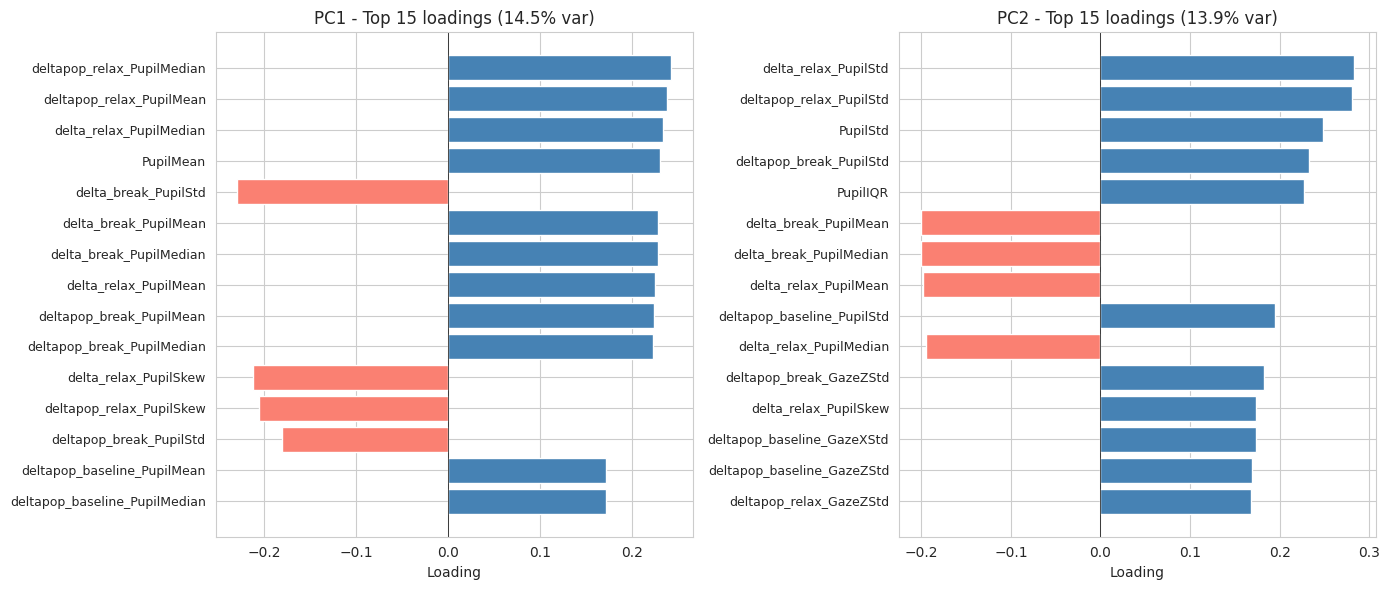

In [38]:
n_top = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, ax in enumerate(axes):
    pc = f"PC{i+1}"
    top = loadings[pc].abs().nlargest(n_top).index
    vals = loadings.loc[top, pc]
    colors = ["steelblue" if v > 0 else "salmon" for v in vals]

    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.set_xlabel("Loading")
    ax.set_title(f"{pc} - Top {n_top} loadings ({pca.explained_variance_ratio_[i]*100:.1f}% var)")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 7b. Loadings heatmap (first 5 PCs)

A heatmap gives an overview of how **all features** relate to the first few PCs.
- **Red** = strong positive loading (feature increases along that PC)
- **Blue** = strong negative loading (feature decreases along that PC)
- **White** = no contribution

Clusters of red/blue reveal groups of features that vary together.

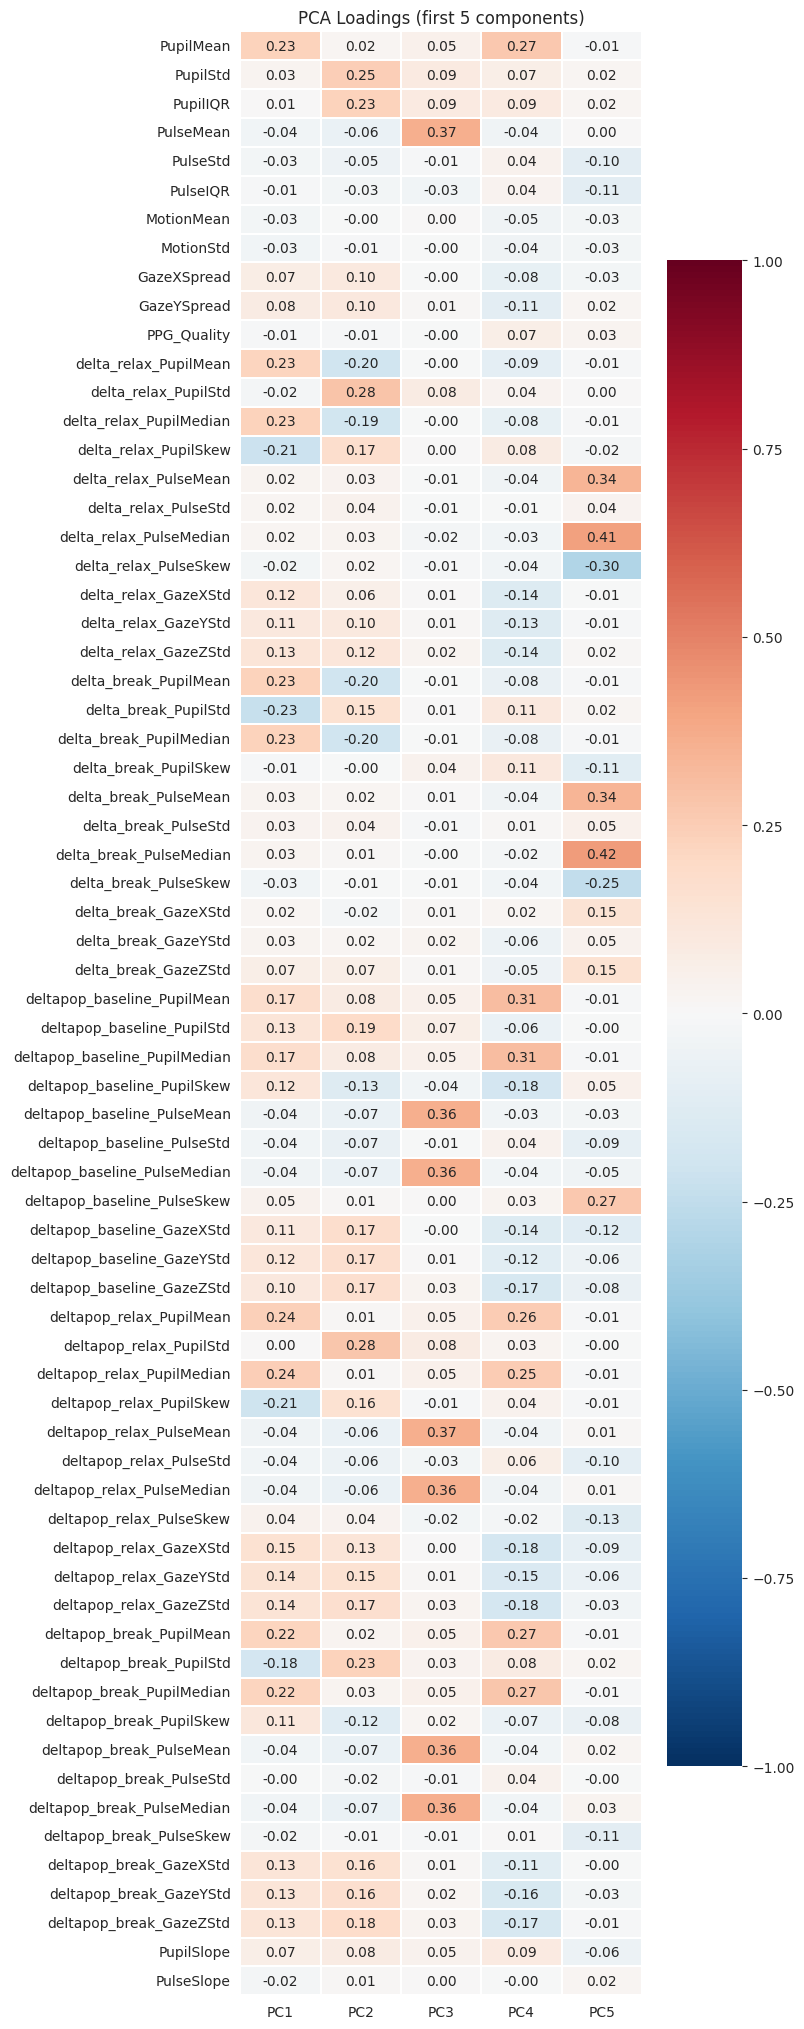

In [39]:
n_pcs_show = min(5, pca.n_components_)

fig, ax = plt.subplots(figsize=(8, max(10, len(feature_cols) * 0.3)))
sns.heatmap(loadings.iloc[:, :n_pcs_show], annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title(f"PCA Loadings (first {n_pcs_show} components)")
plt.tight_layout()
plt.show()

### 7c. Feature loadings in PC1-PC2 space

Each dot is a feature positioned by its PC1 and PC2 loading. Features further from the origin contribute more.
The dashed circles are equal-magnitude contours. Only the top 15 features are labeled.

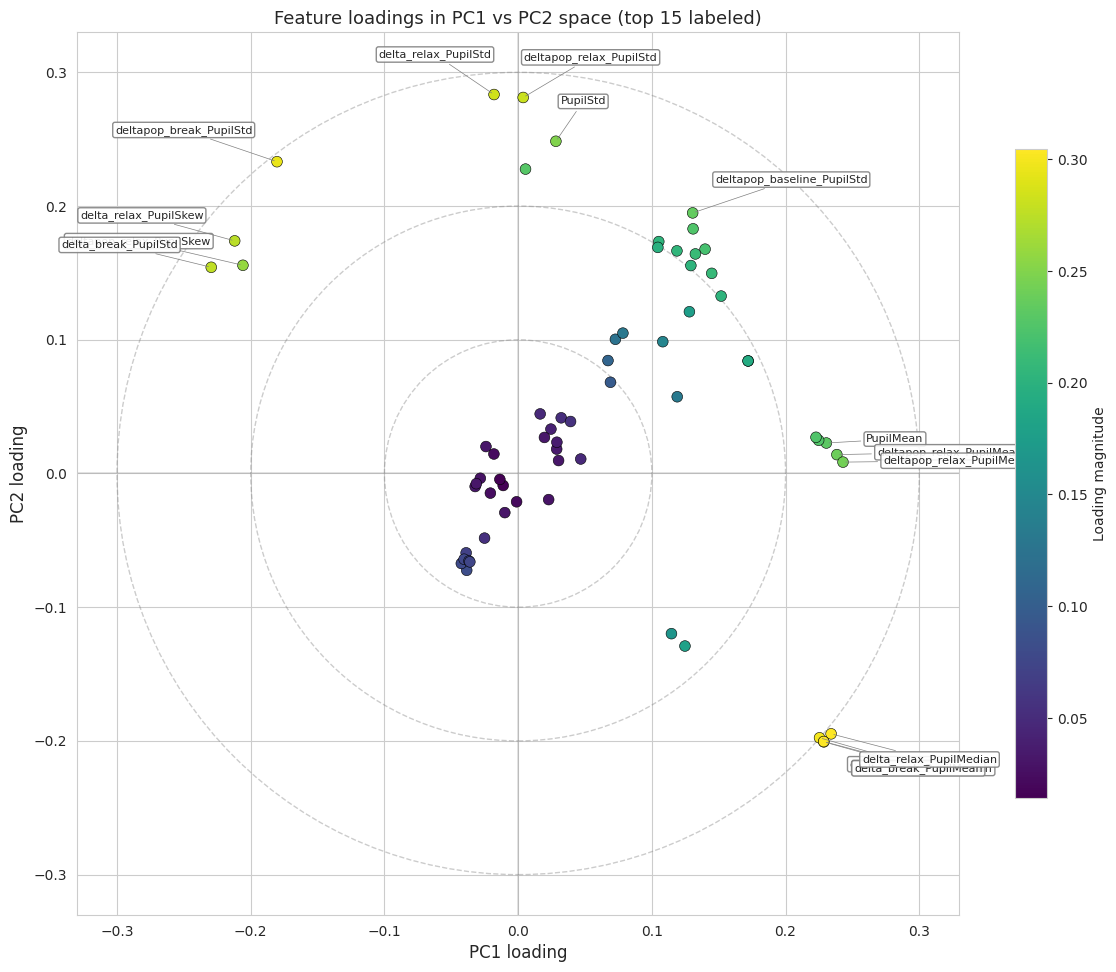

In [40]:
lx = loadings["PC1"].values
ly = loadings["PC2"].values
names = loadings.index.tolist()
magnitude = np.sqrt(lx**2 + ly**2)

fig, ax = plt.subplots(figsize=(12, 10))

# All features as dots
sc = ax.scatter(lx, ly, c=magnitude, cmap="viridis", s=60,
                edgecolors="black", linewidths=0.4, zorder=3)
plt.colorbar(sc, ax=ax, label="Loading magnitude", shrink=0.7)

# Reference circles
for r in [0.1, 0.2, 0.3]:
    circle = plt.Circle((0, 0), r, fill=False, linestyle="--", color="grey", alpha=0.4)
    ax.add_patch(circle)

# Label top 15 by magnitude
n_label = 15
top_idx = np.argsort(magnitude)[-n_label:]

for idx in top_idx:
    x, y = lx[idx], ly[idx]
    name = names[idx]

    # Push label outward so it doesn't sit on the dot
    dist = magnitude[idx]
    nudge = 0.03
    tx = x + (x / dist) * nudge if dist > 0 else x + nudge
    ty = y + (y / dist) * nudge if dist > 0 else y + nudge
    ha = "left" if x >= 0 else "right"

    ax.annotate(
        name, xy=(x, y), xytext=(tx, ty),
        fontsize=8, ha=ha, va="center",
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.9),
    )

ax.set_xlabel("PC1 loading", fontsize=12)
ax.set_ylabel("PC2 loading", fontsize=12)
ax.set_title("Feature loadings in PC1 vs PC2 space (top 15 labeled)", fontsize=13)
ax.axhline(0, color="grey", linewidth=0.3)
ax.axvline(0, color="grey", linewidth=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. Correlation of PCs with STAI

Finally, we check if the principal components themselves correlate with anxiety scores.
If a PC strongly correlates with STAI, it means the physiological pattern captured by that PC is related to anxiety.

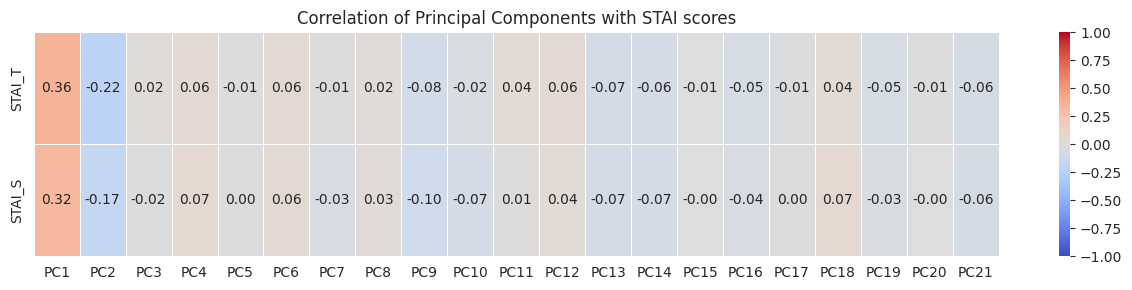

In [41]:
pc_df = pd.DataFrame(X_pca, index=X.index, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
pc_df = pc_df.join(metadata[["STAI_T", "STAI_S"]])

pc_corr = pc_df.corr().loc[["STAI_T", "STAI_S"], [f"PC{i+1}" for i in range(pca.n_components_)]]

fig, ax = plt.subplots(figsize=(max(8, pca.n_components_ * 0.6), 3))
sns.heatmap(pc_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation of Principal Components with STAI scores")
plt.tight_layout()
plt.show()